## Summary of Part 1

In this first part, we covered:

1. **TensorFlow Overview**: Understanding TensorFlow's architecture and capabilities
2. **Creating Tensors**: Using `tf.constant()` to create scalars, vectors, and matrices
3. **Tensor Properties**: Accessing shape, dtype, and numpy representations
4. **Indexing and Slicing**: NumPy-like indexing operations
5. **Tensor Operations**: Mathematical operations, matrix operations, and reductions
6. **NumPy Interoperability**: Seamless conversion between TensorFlow and NumPy
7. **Type Conversions**: Using `tf.cast()` for explicit type conversion (no automatic conversion!)
8. **Variables**: Mutable tensors for storing model parameters
9. **Variable Updates**: Methods like `assign()`, element assignment, and `scatter_nd_update()`

**Key Takeaways:**
- TensorFlow tensors behave like NumPy arrays with GPU support
- TensorFlow uses 32-bit precision by default (NumPy uses 64-bit)
- No automatic type conversion - use `tf.cast()` explicitly
- Variables are mutable and used for model parameters
- Keras handles most variable management automatically

**Next Steps:**
In Part 2, we'll explore:
- Other data structures (sparse tensors, ragged tensors, etc.)
- Custom loss functions
- Custom metrics, activation functions, and initializers
- Custom layers and models

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import keras


c:\Users\ASUS\anaconda3\envs\conda_env\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [3]:
# Other useful variable operations
v = tf.Variable([[1., 2., 3.], [4., 5., 6.]])

# assign_add() - Add a value to the variable
v.assign_add([[1., 1., 1.], [1., 1., 1.]])
print("After v.assign_add([[1., 1., 1.], [1., 1., 1.]]):")
print(v.numpy())
print()

# assign_sub() - Subtract a value from the variable
v.assign_sub([[0.5, 0.5, 0.5], [0.5, 0.5, 0.5]])
print("After v.assign_sub([[0.5, 0.5, 0.5], [0.5, 0.5, 0.5]]):")
print(v.numpy())

After v.assign_add([[1., 1., 1.], [1., 1., 1.]]):
[[2. 3. 4.]
 [5. 6. 7.]]

After v.assign_sub([[0.5, 0.5, 0.5], [0.5, 0.5, 0.5]]):
[[1.5 2.5 3.5]
 [4.5 5.5 6.5]]


In [4]:
# Method 4: scatter_nd_update() - Update specific indices
# This is useful for updating multiple non-contiguous elements
v.scatter_nd_update(indices=[[0, 0], [1, 2]], updates=[100., 200.])
print("After v.scatter_nd_update(indices=[[0, 0], [1, 2]], updates=[100., 200.]):")
print(v.numpy())
print()

print("Explanation:")
print("- Index [0, 0] was updated to 100.0")
print("- Index [1, 2] was updated to 200.0")

After v.scatter_nd_update(indices=[[0, 0], [1, 2]], updates=[100., 200.]):
[[100.    2.5   3.5]
 [  4.5   5.5 200. ]]

Explanation:
- Index [0, 0] was updated to 100.0
- Index [1, 2] was updated to 200.0


In [5]:
# Method 3: Slice assignment - Update a slice
v[:, 2].assign([0., 1.])
print("After v[:, 2].assign([0., 1.]):")
print(v.numpy())
print()

After v[:, 2].assign([0., 1.]):
[[100.    2.5   0. ]
 [  4.5   5.5   1. ]]



In [6]:
# Method 2: Element assignment - Update a single element
v[0, 1].assign(42)
print("After v[0, 1].assign(42):")
print(v.numpy())
print()

After v[0, 1].assign(42):
[[100.   42.    0. ]
 [  4.5   5.5   1. ]]



In [7]:
# Method 1: assign() - Replace entire variable
v.assign(2 * v)
print("After v.assign(2 * v):")
print(v.numpy())
print()

After v.assign(2 * v):
[[200.  84.   0.]
 [  9.  11.   2.]]



In [8]:
# Create a variable for demonstration
v = tf.Variable([[1., 2., 3.], [4., 5., 6.]])
print("Initial variable:")
print(v.numpy())
print()

Initial variable:
[[1. 2. 3.]
 [4. 5. 6.]]



## 3.7 Variable Operations and Updates

Variables provide several methods for updating their values:
- `assign()`: Replace the entire variable or update all elements
- Element assignment: Update individual elements
- Slice assignment: Update slices of the variable
- `scatter_nd_update()`: Update specific indices

In [9]:
# Variables can be modified, but regular tensors cannot
regular_tensor = tf.constant([[1., 2., 3.], [4., 5., 6.]])

# Try to modify a regular tensor (will fail)
try:
    regular_tensor[0, 0] = 100
except Exception as e:
    print("Cannot modify a regular tensor:")
    print(f"{type(e).__name__}: {e}")
    print()

print("But variables CAN be modified (we'll see how in the next section)")

Cannot modify a regular tensor:
TypeError: 'tensorflow.python.framework.ops.EagerTensor' object does not support item assignment

But variables CAN be modified (we'll see how in the next section)


In [10]:
# Create a Variable
v = tf.Variable([[1., 2., 3.], [4., 5., 6.]])

print("Created Variable:")
print(v)
print(f"Type: {type(v)}")
print(f"Shape: {v.shape}")
print(f"Dtype: {v.dtype}")
print(f"NumPy representation:\n{v.numpy()}")

Created Variable:
<tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>
Type: <class 'tensorflow.python.ops.resource_variable_ops.ResourceVariable'>
Shape: (2, 3)
Dtype: <dtype: 'float32'>
NumPy representation:
[[1. 2. 3.]
 [4. 5. 6.]]


## 3.6 Working with Variables

**Variables** are special tensors that can be modified. They are used to store model parameters (weights and biases) that need to be updated during training.

Key differences from regular tensors:
- Variables are **mutable** (can be changed in-place)
- Regular tensors are **immutable** (cannot be changed)
- Variables persist across function calls
- Optimizers can automatically update variables during training

In [11]:
# Other type conversions
print("Type conversion examples:")
print()

# Float to int
float_tensor = tf.constant([1.5, 2.8, 3.2])
int_tensor = tf.cast(float_tensor, tf.int32)
print(f"Float to int: {float_tensor.numpy()} -> {int_tensor.numpy()}")
print()

# Int to float
int_tensor = tf.constant([1, 2, 3])
float_tensor = tf.cast(int_tensor, tf.float32)
print(f"Int to float: {int_tensor.numpy()} -> {float_tensor.numpy()}")
print()

# Bool to int
bool_tensor = tf.constant([True, False, True])
int_tensor = tf.cast(bool_tensor, tf.int32)
print(f"Bool to int: {bool_tensor.numpy()} -> {int_tensor.numpy()}")

Type conversion examples:

Float to int: [1.5 2.8 3.2] -> [1 2 3]

Int to float: [1 2 3] -> [1. 2. 3.]

Bool to int: [ True False  True] -> [1 0 1]


In [12]:
# Solution: Use tf.cast() for explicit type conversion
t1 = tf.constant(2.0)
t2 = tf.constant(40., dtype=tf.float64)

print(f"t1 dtype: {t1.dtype}")
print(f"t2 dtype: {t2.dtype}")
print()

# Cast t2 from float64 to float32
t2_casted = tf.cast(t2, tf.float32)
print(f"t2_casted dtype: {t2_casted.dtype}")
print()

# Now we can add them
result = t1 + t2_casted
print(f"Result of t1 + tf.cast(t2, tf.float32): {result}")
print(f"Result dtype: {result.dtype}")

t1 dtype: <dtype: 'float32'>
t2 dtype: <dtype: 'float64'>

t2_casted dtype: <dtype: 'float32'>

Result of t1 + tf.cast(t2, tf.float32): 42.0
Result dtype: <dtype: 'float32'>


In [13]:
# Even different float precisions won't work
try:
    result = tf.constant(2.) + tf.constant(40., dtype=tf.float64)
    print(result)
except Exception as e:
    print("Error when adding float32 and float64:")
    print(f"{type(e).__name__}: {e}")
    print()

Error when adding float32 and float64:
InvalidArgumentError: cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a double tensor [Op:AddV2] name: 



In [14]:
# Attempting to add tensors of different types will fail
try:
    result = tf.constant(2.) + tf.constant(40)
    print(result)
except Exception as e:
    print("Error when adding float32 and int32:")
    print(f"{type(e).__name__}: {e}")
    print()

Error when adding float32 and int32:
InvalidArgumentError: cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a int32 tensor [Op:AddV2] name: 



## 3.5 Type Conversions in TensorFlow

**Important:** TensorFlow does NOT perform automatic type conversions. This is different from NumPy, which often automatically promotes types. If you try to add tensors of different types, TensorFlow will raise an error.

To convert between types, use `tf.cast()`.

In [15]:
# Apply NumPy operations on TensorFlow tensors
t = tf.constant([2., 4., 5.])
print("TensorFlow tensor:")
print(t)
print()

print("NumPy operation on TensorFlow tensor: np.square(t)")
result = np.square(t)
print(result)
print(f"Result type: {type(result)}")

TensorFlow tensor:
tf.Tensor([2. 4. 5.], shape=(3,), dtype=float32)

NumPy operation on TensorFlow tensor: np.square(t)
[ 4. 16. 25.]
Result type: <class 'numpy.ndarray'>


In [16]:
# Apply TensorFlow operations on NumPy arrays
a = np.array([2., 4., 5.])
print("NumPy array:")
print(a)
print()

print("TensorFlow operation on NumPy array: tf.square(a)")
result = tf.square(a)
print(result)
print(f"Result type: {type(result)}")
print()

NumPy array:
[2. 4. 5.]

TensorFlow operation on NumPy array: tf.square(a)
tf.Tensor([ 4. 16. 25.], shape=(3,), dtype=float64)
Result type: <class 'tensorflow.python.framework.ops.EagerTensor'>



In [17]:
# Convert TensorFlow tensor to NumPy array
t = tf.constant([[1., 2., 3.], [4., 5., 6.]])
numpy_from_tf = t.numpy()  # Method 1
numpy_from_tf_2 = np.array(t)  # Method 2

print("TensorFlow tensor to NumPy array:")
print("Method 1: t.numpy()")
print(numpy_from_tf)
print(f"Type: {type(numpy_from_tf)}")
print()

print("Method 2: np.array(t)")
print(numpy_from_tf_2)
print(f"Type: {type(numpy_from_tf_2)}")

TensorFlow tensor to NumPy array:
Method 1: t.numpy()
[[1. 2. 3.]
 [4. 5. 6.]]
Type: <class 'numpy.ndarray'>

Method 2: np.array(t)
[[1. 2. 3.]
 [4. 5. 6.]]
Type: <class 'numpy.ndarray'>


In [18]:
# Convert NumPy array to TensorFlow tensor
tf_from_numpy = tf.constant(a)
print("NumPy to TensorFlow tensor:")
print(tf_from_numpy)
print(f"Type: {type(tf_from_numpy)}")
print(f"Dtype: {tf_from_numpy.dtype}")
print()

# Note the dtype difference: NumPy uses float64, TensorFlow converted to float32
# For consistency, explicitly set dtype
tf_from_numpy_32 = tf.constant(a, dtype=tf.float32)
print("With explicit dtype=tf.float32:")
print(tf_from_numpy_32)
print(f"Dtype: {tf_from_numpy_32.dtype}")

NumPy to TensorFlow tensor:
tf.Tensor([2. 4. 5.], shape=(3,), dtype=float64)
Type: <class 'tensorflow.python.framework.ops.EagerTensor'>
Dtype: <dtype: 'float64'>

With explicit dtype=tf.float32:
tf.Tensor([2. 4. 5.], shape=(3,), dtype=float32)
Dtype: <dtype: 'float32'>


In [19]:
# Create a NumPy array
a = np.array([2., 4., 5.])
print("NumPy array:")
print(a)
print(f"Type: {type(a)}")
print(f"Dtype: {a.dtype}")
print()

NumPy array:
[2. 4. 5.]
Type: <class 'numpy.ndarray'>
Dtype: float64



## 3.4 TensorFlow and NumPy Interoperability

TensorFlow and NumPy work seamlessly together. You can:
- Convert NumPy arrays to TensorFlow tensors
- Convert TensorFlow tensors to NumPy arrays
- Apply TensorFlow operations on NumPy arrays
- Apply NumPy operations on TensorFlow tensors

**Important:** NumPy uses 64-bit precision by default, while TensorFlow uses 32-bit. Always set `dtype=tf.float32` when creating tensors from NumPy arrays for consistency.

In [20]:
# Shape manipulation operations
print("Reshape operations:")
print(f"Original shape: {t.shape}")
print(f"Reshaped to (3, 2):\n{tf.reshape(t, [3, 2])}")
print()

print(f"Flattened to 1D:\n{tf.reshape(t, [-1])}")
print()

# Tile operation (repeat tensor)
print("Tile t (repeat 2 times in row dimension, 3 times in column dimension):")
print(tf.tile(t, [2, 3]))

Reshape operations:
Original shape: (2, 3)
Reshaped to (3, 2):
[[1. 2.]
 [3. 4.]
 [5. 6.]]

Flattened to 1D:
[1. 2. 3. 4. 5. 6.]

Tile t (repeat 2 times in row dimension, 3 times in column dimension):
tf.Tensor(
[[1. 2. 3. 1. 2. 3. 1. 2. 3.]
 [4. 5. 6. 4. 5. 6. 4. 5. 6.]
 [1. 2. 3. 1. 2. 3. 1. 2. 3.]
 [4. 5. 6. 4. 5. 6. 4. 5. 6.]], shape=(4, 9), dtype=float32)


In [21]:
# Reduction operations
print("Reduce operations on tensor t:")
print(f"Mean: {tf.reduce_mean(t)}")
print(f"Sum: {tf.reduce_sum(t)}")
print(f"Max: {tf.reduce_max(t)}")
print(f"Min: {tf.reduce_min(t)}")
print()

# Reduction along specific axis
print("Mean along axis 0 (columns):", tf.reduce_mean(t, axis=0))
print("Mean along axis 1 (rows):", tf.reduce_mean(t, axis=1))

Reduce operations on tensor t:
Mean: 3.5
Sum: 21.0
Max: 6.0
Min: 1.0

Mean along axis 0 (columns): tf.Tensor([2.5 3.5 4.5], shape=(3,), dtype=float32)
Mean along axis 1 (rows): tf.Tensor([2. 5.], shape=(2,), dtype=float32)


In [22]:
# Matrix operations
print("Transpose: tf.transpose(t)")
print(tf.transpose(t))
print()

print("Matrix multiplication: t @ tf.transpose(t)")
print(t @ tf.transpose(t))
print("Result shape:", (t @ tf.transpose(t)).shape)
print()

Transpose: tf.transpose(t)
tf.Tensor(
[[1. 4.]
 [2. 5.]
 [3. 6.]], shape=(3, 2), dtype=float32)

Matrix multiplication: t @ tf.transpose(t)
tf.Tensor(
[[14. 32.]
 [32. 77.]], shape=(2, 2), dtype=float32)
Result shape: (2, 2)



In [23]:
# Element-wise operations
print("Square: tf.square(t)")
print(tf.square(t))
print()

print("Exponential: tf.exp(t)")
print(tf.exp(t))
print()

print("Square root: tf.sqrt(t)")
print(tf.sqrt(t))
print()

Square: tf.square(t)
tf.Tensor(
[[ 1.  4.  9.]
 [16. 25. 36.]], shape=(2, 3), dtype=float32)

Exponential: tf.exp(t)
tf.Tensor(
[[  2.7182817   7.389056   20.085537 ]
 [ 54.59815   148.41316   403.4288   ]], shape=(2, 3), dtype=float32)

Square root: tf.sqrt(t)
tf.Tensor(
[[1.        1.4142135 1.7320508]
 [2.        2.236068  2.4494898]], shape=(2, 3), dtype=float32)



In [24]:
# Basic arithmetic operations
t = tf.constant([[1., 2., 3.], [4., 5., 6.]])

print("Original tensor:")
print(t)
print()

# Addition (element-wise)
print("Addition: t + 10")
print(t + 10)
print("Equivalent: tf.add(t, 10)")
print(tf.add(t, 10))
print()

# Multiplication (element-wise)
print("Multiplication: t * 2")
print(t * 2)
print()

Original tensor:
tf.Tensor(
[[1. 2. 3.]
 [4. 5. 6.]], shape=(2, 3), dtype=float32)

Addition: t + 10
tf.Tensor(
[[11. 12. 13.]
 [14. 15. 16.]], shape=(2, 3), dtype=float32)
Equivalent: tf.add(t, 10)
tf.Tensor(
[[11. 12. 13.]
 [14. 15. 16.]], shape=(2, 3), dtype=float32)

Multiplication: t * 2
tf.Tensor(
[[ 2.  4.  6.]
 [ 8. 10. 12.]], shape=(2, 3), dtype=float32)



## 3.3 Tensor Operations and Math

TensorFlow provides a rich set of mathematical operations. You can use both operator syntax (`+`, `-`, `*`, `@`) and function syntax (`tf.add()`, `tf.multiply()`, etc.).

In [25]:
# Slicing: select all rows, columns from index 1 onwards
print("Slicing [:, 1:] - all rows, columns 1 and 2:")
print(t[:, 1:])
print()

# Select specific row
print("First row [0, :]:")
print(t[0, :])
print()

# Select specific column
print("Second column [:, 1]:")
print(t[:, 1])
print()

# Select single element
print("Element at position [1, 2]:")
print(t[1, 2])

Slicing [:, 1:] - all rows, columns 1 and 2:
tf.Tensor(
[[2. 3.]
 [5. 6.]], shape=(2, 2), dtype=float32)

First row [0, :]:
tf.Tensor([1. 2. 3.], shape=(3,), dtype=float32)

Second column [:, 1]:
tf.Tensor([2. 5.], shape=(2,), dtype=float32)

Element at position [1, 2]:
tf.Tensor(6.0, shape=(), dtype=float32)


In [26]:
# Create a sample matrix
t = tf.constant([[1., 2., 3.], [4., 5., 6.]])
print("Original matrix:")
print(t)
print()

Original matrix:
tf.Tensor(
[[1. 2. 3.]
 [4. 5. 6.]], shape=(2, 3), dtype=float32)



## 3.2 Indexing and Slicing Tensors

TensorFlow supports NumPy-like indexing and slicing operations. This makes it easy to extract specific elements, rows, or columns from tensors.

In [27]:
# Create a matrix (2-dimensional tensor)
matrix = tf.constant([[1., 2., 3.], [4., 5., 6.]])
print("Matrix tensor:")
print(matrix)
print(f"Shape: {matrix.shape}")
print(f"Dtype: {matrix.dtype}")
print(f"NumPy representation:\n{matrix.numpy()}")

Matrix tensor:
tf.Tensor(
[[1. 2. 3.]
 [4. 5. 6.]], shape=(2, 3), dtype=float32)
Shape: (2, 3)
Dtype: <dtype: 'float32'>
NumPy representation:
[[1. 2. 3.]
 [4. 5. 6.]]


In [28]:
# Create a vector (1-dimensional tensor)
vector = tf.constant([1., 2., 3.])
print("Vector tensor:")
print(vector)
print(f"Shape: {vector.shape}")
print(f"Dtype: {vector.dtype}")
print()

Vector tensor:
tf.Tensor([1. 2. 3.], shape=(3,), dtype=float32)
Shape: (3,)
Dtype: <dtype: 'float32'>



In [29]:
# Create a scalar (0-dimensional tensor)
scalar = tf.constant(42)
print("Scalar tensor:")
print(scalar)
print(f"Shape: {scalar.shape}")
print(f"Dtype: {scalar.dtype}")
print(f"NumPy value: {scalar.numpy()}")
print()

Scalar tensor:
tf.Tensor(42, shape=(), dtype=int32)
Shape: ()
Dtype: <dtype: 'int32'>
NumPy value: 42



# 3. Using TensorFlow like NumPy

## 3.1 Create and Inspect Tensors

Tensors are the fundamental data structure in TensorFlow. They are multi-dimensional arrays, similar to NumPy arrays. Let's create tensors of different shapes using `tf.constant()`.

# 2. TensorFlow Quick Tour

## What TensorFlow Offers:
- **NumPy-like core** with GPU support
- **Distributed computing** across devices and servers
- **Just-in-time (JIT) compiler** for optimization
- **Portable computation graphs**
- **Autodiff** with excellent optimizers (RMSProp, Nadam)
- **Rich ecosystem**: TensorBoard, TensorFlow Extended (TFX), TensorFlow Hub, model garden

## Architecture:
- **High-level APIs**: `tf.keras`, `tf.data`
- **Lower-level Python API** for direct tensor manipulation
- **Efficient C++ execution engine** with GPU/TPU support
- **Cross-platform**: Windows, Linux, macOS, mobile (TensorFlow Lite), web (TensorFlow.js)

In [30]:
# Import necessary libraries
import tensorflow as tf
import numpy as np

# Display TensorFlow version
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.15.0
NumPy version: 1.26.4


# 1. Import Required Libraries

Let's start by importing TensorFlow and NumPy, then verify our TensorFlow installation.

# Chapter 12: Custom Models and Training with TensorFlow - Part 1

## Overview

This notebook explores TensorFlow's lower-level Python API, enabling you to build custom loss functions, metrics, layers, models, initializers, regularizers, weight constraints, and custom training loops. 

**Key Points:**
- While 95% of use cases only require `tf.keras`, understanding these advanced techniques provides flexibility for specialized architectures
- TensorFlow provides a NumPy-like core with GPU support
- It includes distributed computing, JIT compilation, and automatic differentiation
- Rich ecosystem: TensorBoard, TensorFlow Extended (TFX), TensorFlow Hub

In this first part, we'll cover:
1. TensorFlow basics and quick tour
2. Using TensorFlow like NumPy (tensors, operations, interoperability)
3. Type conversions
4. Variables

# Part 2: Other Data Structures and Custom Loss Functions

In this section, we'll explore:
1. Other TensorFlow data structures (sparse tensors, ragged tensors, etc.)
2. Custom loss functions with different approaches

# 4. Other Data Structures

Beyond regular tensors and variables, TensorFlow provides specialized data structures for efficient handling of different types of data:
- **Sparse tensors**: For tensors with mostly zeros
- **Tensor arrays**: Lists of tensors
- **Ragged tensors**: Lists of lists with varying lengths
- **String tensors**: For text data
- **Sets**: For set operations
- **Queues**: For data pipelines

## 4.1 Sparse Tensors

Sparse tensors are efficient for storing tensors that are mostly zeros. Instead of storing all values, they only store the non-zero values and their indices.

In [31]:
# Create a sparse tensor
# Format: indices, values, and dense shape
indices = [[0, 1], [1, 0], [2, 3]]  # Positions of non-zero values
values = [1., 2., 3.]  # The non-zero values
dense_shape = [3, 4]  # Shape of the dense tensor

sparse_tensor = tf.SparseTensor(indices=indices, values=values, dense_shape=dense_shape)

print("Sparse Tensor:")
print(sparse_tensor)
print()

# Convert to dense tensor to see the actual values
dense_version = tf.sparse.to_dense(sparse_tensor)
print("Dense version:")
print(dense_version.numpy())

Sparse Tensor:
SparseTensor(indices=tf.Tensor(
[[0 1]
 [1 0]
 [2 3]], shape=(3, 2), dtype=int64), values=tf.Tensor([1. 2. 3.], shape=(3,), dtype=float32), dense_shape=tf.Tensor([3 4], shape=(2,), dtype=int64))

Dense version:
[[0. 1. 0. 0.]
 [2. 0. 0. 0.]
 [0. 0. 0. 3.]]


In [32]:
# Sparse tensor operations
s1 = tf.SparseTensor(indices=[[0, 1], [1, 0]], values=[1., 2.], dense_shape=[2, 3])
s2 = tf.SparseTensor(indices=[[0, 0], [1, 1]], values=[3., 4.], dense_shape=[2, 3])

# Addition
s_sum = tf.sparse.add(s1, s2)
print("Sparse addition result (dense):")
print(tf.sparse.to_dense(s_sum).numpy())
print()

# Matrix multiplication (sparse @ dense)
dense_matrix = tf.constant([[1.], [2.], [3.]])
result = tf.sparse.sparse_dense_matmul(s1, dense_matrix)
print("Sparse-dense matrix multiplication:")
print(result.numpy())

Sparse addition result (dense):
[[3. 1. 0.]
 [2. 4. 0.]]

Sparse-dense matrix multiplication:
[[2.]
 [2.]]


## 4.2 Ragged Tensors

Ragged tensors are useful for sequences with varying lengths (e.g., sentences with different word counts, time series with different lengths).

In [33]:
# Create a ragged tensor - lists of different lengths
ragged = tf.ragged.constant([[1, 2, 3], [4, 5], [6, 7, 8, 9], [10]])

print("Ragged Tensor:")
print(ragged)
print()

print("Shape:", ragged.shape)
print("Number of rows:", ragged.nrows())
print()

# Access elements
print("First row:", ragged[0].numpy())
print("Second row:", ragged[1].numpy())

Ragged Tensor:
<tf.RaggedTensor [[1, 2, 3], [4, 5], [6, 7, 8, 9], [10]]>

Shape: (4, None)
Number of rows: tf.Tensor(4, shape=(), dtype=int64)

First row: [1 2 3]
Second row: [4 5]


In [34]:
# Operations on ragged tensors
print("Element-wise operations:")
print("ragged * 2:")
print((ragged * 2))
print()

# Convert to dense (pads with zeros)
dense_from_ragged = ragged.to_tensor(default_value=0)
print("Converted to dense (padded with 0):")
print(dense_from_ragged.numpy())
print()

# Can also specify different padding value
dense_from_ragged_neg = ragged.to_tensor(default_value=-1)
print("Converted to dense (padded with -1):")
print(dense_from_ragged_neg.numpy())

Element-wise operations:
ragged * 2:
<tf.RaggedTensor [[2, 4, 6], [8, 10], [12, 14, 16, 18], [20]]>

Converted to dense (padded with 0):
[[ 1  2  3  0]
 [ 4  5  0  0]
 [ 6  7  8  9]
 [10  0  0  0]]

Converted to dense (padded with -1):
[[ 1  2  3 -1]
 [ 4  5 -1 -1]
 [ 6  7  8  9]
 [10 -1 -1 -1]]


## 4.3 String Tensors

TensorFlow can handle string tensors for text processing.

In [35]:
# Create string tensors
strings = tf.constant(["Hello", "TensorFlow", "World"])
print("String tensor:")
print(strings)
print(f"Dtype: {strings.dtype}")
print()

# String operations
print("Length of each string:")
print(tf.strings.length(strings).numpy())
print()

# Convert to uppercase
print("Uppercase:")
print(tf.strings.upper(strings).numpy())
print()

# Split strings
sentence = tf.constant("TensorFlow is awesome")
words = tf.strings.split(sentence)
print(f"Split '{sentence.numpy().decode()}' into words:")
print([word.numpy().decode() for word in words])

String tensor:
tf.Tensor([b'Hello' b'TensorFlow' b'World'], shape=(3,), dtype=string)
Dtype: <dtype: 'string'>

Length of each string:
[ 5 10  5]

Uppercase:
[b'HELLO' b'TENSORFLOW' b'WORLD']

Split 'TensorFlow is awesome' into words:
['TensorFlow', 'is', 'awesome']


## 4.4 Sets

TensorFlow provides set operations for handling unique elements and set operations.

In [36]:
# Set operations
set_a = tf.constant([[1, 2, 3], [4, 5, 6]])
set_b = tf.constant([[2, 3, 4], [5, 6, 7]])

print("Set A:")
print(set_a.numpy())
print("\nSet B:")
print(set_b.numpy())
print()

# Set difference
diff = tf.sets.difference(set_a, set_b)
print("Set A - Set B (difference):")
print(tf.sparse.to_dense(diff).numpy())
print()

# Set intersection
intersect = tf.sets.intersection(set_a, set_b)
print("Set A ∩ Set B (intersection):")
print(tf.sparse.to_dense(intersect).numpy())
print()

# Set union
union = tf.sets.union(set_a, set_b)
print("Set A ∪ Set B (union):")
print(tf.sparse.to_dense(union).numpy())

Set A:
[[1 2 3]
 [4 5 6]]

Set B:
[[2 3 4]
 [5 6 7]]

Set A - Set B (difference):
[[1]
 [4]]

Set A ∩ Set B (intersection):
[[2 3]
 [5 6]]

Set A ∪ Set B (union):
[[1 2 3 4]
 [4 5 6 7]]


# 5. Customizing Models and Training Algorithms

## 5.1 Custom Loss Functions

Custom loss functions allow you to define specialized objectives for your models. TensorFlow/Keras provides three approaches:
1. **Simple function**: Quick and easy
2. **Configurable with closure**: For hyperparameters
3. **Class-based**: For saving/loading models with custom losses

Let's implement the **Huber loss** as an example. Huber loss is less sensitive to outliers than MSE:
- For small errors (|error| < threshold): uses squared loss
- For large errors (|error| ≥ threshold): uses linear loss

## 5.2 Approach 1: Simple Function

The simplest way to create a custom loss is to define a function that takes `y_true` and `y_pred` as arguments.

In [37]:
# Import keras
from tensorflow import keras

def huber_fn(y_true, y_pred):
    """
    Huber loss: less sensitive to outliers than MSE
    - Uses squared loss for small errors
    - Uses linear loss for large errors
    """
    error = y_true - y_pred
    is_small_error = tf.abs(error) < 1
    squared_loss = tf.square(error) / 2
    linear_loss = tf.abs(error) - 0.5
    return tf.where(is_small_error, squared_loss, linear_loss)

# Test the loss function
y_true = tf.constant([0., 1., 2., 3., 4.])
y_pred = tf.constant([0.5, 1.5, 1.5, 3.2, 5.0])

loss = huber_fn(y_true, y_pred)
print("True values:", y_true.numpy())
print("Predicted values:", y_pred.numpy())
print("Errors:", (y_true - y_pred).numpy())
print("Huber loss:", loss.numpy())
print(f"Mean loss: {tf.reduce_mean(loss).numpy():.4f}")

True values: [0. 1. 2. 3. 4.]
Predicted values: [0.5 1.5 1.5 3.2 5. ]
Errors: [-0.5        -0.5         0.5        -0.20000005 -1.        ]
Huber loss: [0.125      0.125      0.125      0.02000001 0.5       ]
Mean loss: 0.1790


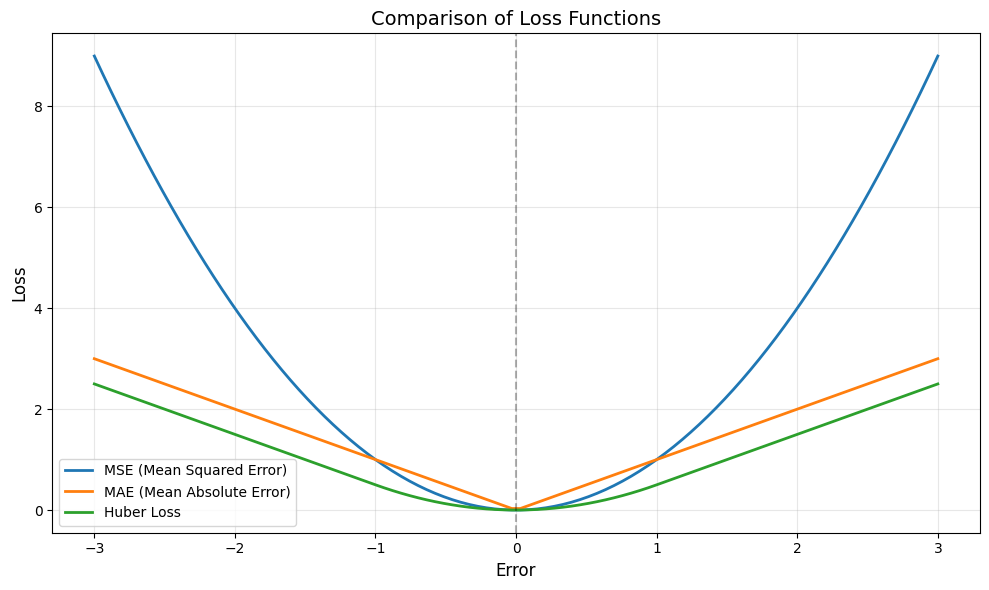

Notice how Huber loss combines the best of both:
- Like MSE for small errors (smooth gradient)
- Like MAE for large errors (less sensitive to outliers)


In [38]:
# Visualize how Huber loss compares to MSE and MAE
import matplotlib.pyplot as plt

# Generate error values
errors = np.linspace(-3, 3, 100)
errors_tf = tf.constant(errors, dtype=tf.float32)

# Calculate different losses
mse_loss = tf.square(errors_tf).numpy()
mae_loss = tf.abs(errors_tf).numpy()
huber_loss = huber_fn(tf.constant(0.), errors_tf).numpy()

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(errors, mse_loss, label='MSE (Mean Squared Error)', linewidth=2)
plt.plot(errors, mae_loss, label='MAE (Mean Absolute Error)', linewidth=2)
plt.plot(errors, huber_loss, label='Huber Loss', linewidth=2)
plt.xlabel('Error', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Comparison of Loss Functions', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("Notice how Huber loss combines the best of both:")
print("- Like MSE for small errors (smooth gradient)")
print("- Like MAE for large errors (less sensitive to outliers)")

In [39]:
# Use the custom loss in a model
# Create sample regression data
np.random.seed(42)
X_train = np.random.randn(1000, 10).astype(np.float32)
y_train = (X_train.sum(axis=1) + np.random.randn(1000) * 0.5).astype(np.float32)

# Build a simple model
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[10]),
    keras.layers.Dense(1)
])

# Compile with custom loss
model.compile(loss=huber_fn, optimizer="adam", metrics=["mae"])

print("Model compiled with custom Huber loss function")
print("\nModel summary:")
model.summary()

Model compiled with custom Huber loss function

Model summary:


c:\Users\ASUS\anaconda3\envs\conda_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361 (1.41 KB)

 Trainable params: 361 (1.41 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Train the model
print("Training model with custom Huber loss...")
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2, verbose=0)

print(f"\nFinal training loss: {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")

Training model with custom Huber loss...

Final training loss: 0.1931
Final validation loss: 0.1490


## 5.3 Approach 2: Configurable Loss with Closure

When you need to configure hyperparameters (like the threshold for Huber loss), use a closure. This is a function that returns another function.

In [41]:
def create_huber(threshold=1.0):
    """
    Factory function to create Huber loss with configurable threshold
    
    Args:
        threshold: The point where loss transitions from quadratic to linear
    
    Returns:
        A loss function with the specified threshold
    """
    def huber_fn(y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < threshold
        squared_loss = tf.square(error) / 2
        linear_loss = threshold * tf.abs(error) - threshold**2 / 2
        return tf.where(is_small_error, squared_loss, linear_loss)
    return huber_fn

# Create Huber loss with different thresholds
huber_1 = create_huber(threshold=1.0)
huber_2 = create_huber(threshold=2.0)
huber_0_5 = create_huber(threshold=0.5)

# Test with same error
error = tf.constant([0.5, 1.0, 1.5, 2.0, 3.0])
y_true = tf.constant(0.)

print("Error values:", error.numpy())
print(f"Huber(threshold=0.5): {huber_0_5(y_true, error).numpy()}")
print(f"Huber(threshold=1.0): {huber_1(y_true, error).numpy()}")
print(f"Huber(threshold=2.0): {huber_2(y_true, error).numpy()}")

Error values: [0.5 1.  1.5 2.  3. ]
Huber(threshold=0.5): [0.125 0.375 0.625 0.875 1.375]
Huber(threshold=1.0): [0.125 0.5   1.    1.5   2.5  ]
Huber(threshold=2.0): [0.125 0.5   1.125 2.    4.   ]


In [42]:
# Use in model with custom threshold
model_custom = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[10]),
    keras.layers.Dense(1)
])

# Compile with threshold=2.0
model_custom.compile(loss=create_huber(2.0), optimizer="adam", metrics=["mae"])

print("Model compiled with Huber loss (threshold=2.0)")
history_custom = model_custom.fit(X_train, y_train, epochs=10, validation_split=0.2, verbose=0)

print(f"\nFinal training loss: {history_custom.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history_custom.history['val_loss'][-1]:.4f}")

Model compiled with Huber loss (threshold=2.0)

Final training loss: 0.2681
Final validation loss: 0.2078


## 5.4 Approach 3: Class-Based Loss (Best for Saving/Loading)

The class-based approach is the most robust. It automatically saves hyperparameters and makes models easy to save and load.

In [43]:
class HuberLoss(keras.losses.Loss):
    """
    Huber loss implemented as a Keras Loss class.
    
    This approach automatically handles:
    - Saving/loading models
    - Hyperparameter persistence via get_config()
    - Integration with Keras ecosystem
    """
    def __init__(self, threshold=1.0, **kwargs):
        self.threshold = threshold
        super().__init__(**kwargs)
    
    def call(self, y_true, y_pred):
        """Compute the Huber loss"""
        error = y_true - y_pred
        is_small_error = tf.abs(error) < self.threshold
        squared_loss = tf.square(error) / 2
        linear_loss = self.threshold * tf.abs(error) - self.threshold**2 / 2
        return tf.where(is_small_error, squared_loss, linear_loss)
    
    def get_config(self):
        """Save hyperparameters for model serialization"""
        base_config = super().get_config()
        return {**base_config, "threshold": self.threshold}

# Create an instance of the loss
huber_loss_obj = HuberLoss(threshold=2.0)

# Test the loss
y_true = tf.constant([0., 1., 2., 3., 4.])
y_pred = tf.constant([0.5, 1.5, 1.5, 3.2, 5.0])

loss = huber_loss_obj(y_true, y_pred)
print("Using HuberLoss class:")
print("True values:", y_true.numpy())
print("Predicted values:", y_pred.numpy())
print("Loss per sample:", loss.numpy())
print(f"Mean loss: {tf.reduce_mean(loss).numpy():.4f}")

Using HuberLoss class:
True values: [0. 1. 2. 3. 4.]
Predicted values: [0.5 1.5 1.5 3.2 5. ]
Loss per sample: 0.17899999
Mean loss: 0.1790


In [44]:
# Use in a model
model_class = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[10]),
    keras.layers.Dense(1)
])

# Compile with class-based loss
model_class.compile(loss=HuberLoss(2.0), optimizer="adam", metrics=["mae"])

print("Model compiled with HuberLoss class (threshold=2.0)")
history_class = model_class.fit(X_train, y_train, epochs=10, validation_split=0.2, verbose=0)

print(f"\nFinal training loss: {history_class.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history_class.history['val_loss'][-1]:.4f}")

Model compiled with HuberLoss class (threshold=2.0)

Final training loss: 3.4704
Final validation loss: 3.0596


## 5.5 Saving and Loading Models with Custom Loss

The class-based approach makes it easy to save and load models. Let's demonstrate this.

In [45]:
# Save the model
model_path = "my_model_with_custom_loss.keras"
model_class.save(model_path)
print(f"Model saved to {model_path}")
print()

# Load the model - need to specify custom objects
loaded_model = keras.models.load_model(
    model_path,
    custom_objects={"HuberLoss": HuberLoss}
)

print("Model loaded successfully!")
print()

# Verify the loaded model works
sample_input = X_train[:5]
original_prediction = model_class.predict(sample_input, verbose=0)
loaded_prediction = loaded_model.predict(sample_input, verbose=0)

print("Predictions match:", np.allclose(original_prediction, loaded_prediction))
print(f"Original prediction: {original_prediction.ravel()}")
print(f"Loaded prediction: {loaded_prediction.ravel()}")

Model saved to my_model_with_custom_loss.keras

Model loaded successfully!

Predictions match: True
Original prediction: [-0.08993778 -0.21651445  0.20387584 -0.03648381  0.10092384]
Loaded prediction: [-0.08993778 -0.21651445  0.20387584 -0.03648381  0.10092384]


In [46]:
# For simple function-based losses, you need to provide the function when loading
# Save a model with function-based loss
model_func = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[10]),
    keras.layers.Dense(1)
])
model_func.compile(loss=huber_fn, optimizer="adam")
model_func.fit(X_train[:100], y_train[:100], epochs=3, verbose=0)

model_func_path = "my_model_with_func_loss.keras"
model_func.save(model_func_path)
print(f"Function-based model saved to {model_func_path}")

# Load it back
loaded_func_model = keras.models.load_model(
    model_func_path,
    custom_objects={"huber_fn": huber_fn}  # Must provide the function
)
print("Function-based model loaded successfully!")
print("\nNote: For function-based losses, you must provide the function when loading.")

Function-based model saved to my_model_with_func_loss.keras
Function-based model loaded successfully!

Note: For function-based losses, you must provide the function when loading.


## Summary of Part 2

In this section, we covered:

1. **Other Data Structures**:
   - **Sparse Tensors**: Efficient storage for mostly-zero tensors
   - **Ragged Tensors**: Handle sequences with varying lengths
   - **String Tensors**: Text processing capabilities
   - **Sets**: Set operations (union, intersection, difference)

2. **Custom Loss Functions** - Three approaches:
   - **Simple Function**: Quick and easy, just define `def loss_fn(y_true, y_pred)`
   - **Configurable with Closure**: Use a factory function for hyperparameters
   - **Class-Based (Recommended)**: Inherit from `keras.losses.Loss` for:
     - Automatic hyperparameter saving via `get_config()`
     - Easy model serialization
     - Better integration with Keras

**Key Takeaways:**
- Use sparse tensors for memory efficiency with sparse data
- Ragged tensors are perfect for variable-length sequences
- For custom losses: start simple, use classes when you need to save models
- The Huber loss is a robust alternative to MSE (less sensitive to outliers)

**Next Steps:**
In Part 3, we'll explore:
- Custom activation functions, initializers, regularizers, and constraints
- Custom metrics (simple and streaming)
- Custom layers (stateless and stateful)

# Part 3: Custom Components and Metrics

In this section, we'll explore:
1. Custom activation functions, initializers, regularizers, and constraints
2. Custom metrics (simple and streaming)

# 6. Custom Activation Functions, Initializers, Regularizers, and Constraints

Keras allows you to customize various components of neural networks. You can define custom:
- **Activation functions**: How neurons transform their inputs
- **Initializers**: How weights are initialized
- **Regularizers**: How to penalize large weights
- **Constraints**: How to restrict weight values

Each can be implemented as a simple function or as a class for more complex behavior.

## 6.1 Custom Activation Function

Let's implement a custom softplus activation function. Softplus is a smooth approximation of ReLU: $f(x) = \log(1 + e^x)$

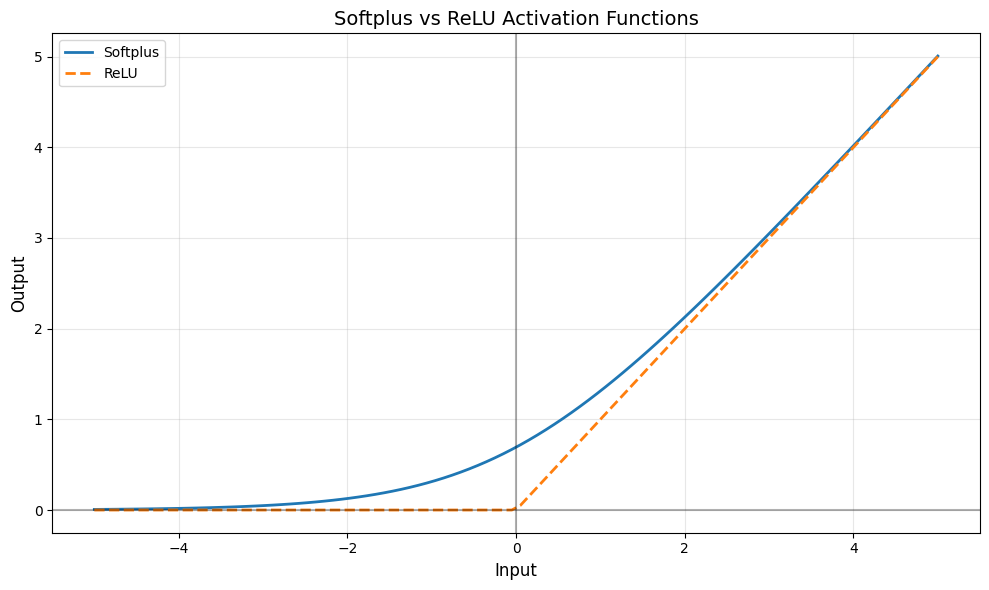

Softplus is a smooth approximation of ReLU (no sharp corner at x=0)


In [47]:
def my_softplus(z):
    """
    Custom softplus activation function: log(1 + exp(z))
    A smooth approximation of ReLU
    """
    return tf.math.log(tf.exp(z) + 1.0)

# Test the activation function
x = tf.linspace(-5.0, 5.0, 100)
y_softplus = my_softplus(x)
y_relu = tf.nn.relu(x)

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(x.numpy(), y_softplus.numpy(), label='Softplus', linewidth=2)
plt.plot(x.numpy(), y_relu.numpy(), label='ReLU', linewidth=2, linestyle='--')
plt.xlabel('Input', fontsize=12)
plt.ylabel('Output', fontsize=12)
plt.title('Softplus vs ReLU Activation Functions', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

print("Softplus is a smooth approximation of ReLU (no sharp corner at x=0)")

In [48]:
# Use custom activation in a layer
layer_with_custom_activation = keras.layers.Dense(10, activation=my_softplus)

# Build a model with custom activation
model_custom_act = keras.models.Sequential([
    keras.layers.Dense(30, activation=my_softplus, input_shape=[10]),
    keras.layers.Dense(20, activation=my_softplus),
    keras.layers.Dense(1)
])

print("Model with custom softplus activation:")
model_custom_act.summary()

Model with custom softplus activation:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 971 (3.79 KB)

 Trainable params: 971 (3.79 KB)

 Non-trainable params: 0 (0.00 B)

## 6.2 Custom Initializer

Weight initialization is critical for training neural networks. Let's implement a custom Glorot (Xavier) initializer, which initializes weights with variance proportional to the average of the number of input and output units.

Initialized weights shape: (100, 50)
Mean: -0.0010
Std: 0.1144
Min: -0.4068
Max: 0.4354


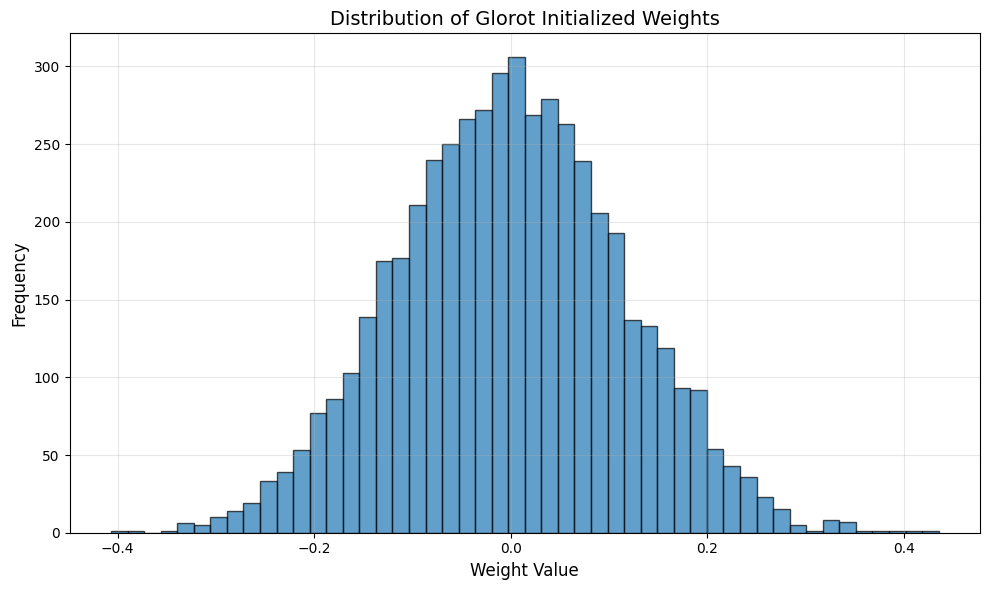

In [49]:
def my_glorot_initializer(shape, dtype=tf.float32):
    """
    Custom Glorot (Xavier) uniform initializer
    Initializes weights from: U[-limit, limit]
    where limit = sqrt(6 / (fan_in + fan_out))
    """
    stddev = tf.sqrt(2. / (shape[0] + shape[1]))
    return tf.random.normal(shape, stddev=stddev, dtype=dtype)

# Test the initializer
weights = my_glorot_initializer(shape=[100, 50])
print(f"Initialized weights shape: {weights.shape}")
print(f"Mean: {tf.reduce_mean(weights).numpy():.4f}")
print(f"Std: {tf.math.reduce_std(weights).numpy():.4f}")
print(f"Min: {tf.reduce_min(weights).numpy():.4f}")
print(f"Max: {tf.reduce_max(weights).numpy():.4f}")

# Visualize the distribution
plt.figure(figsize=(10, 6))
plt.hist(weights.numpy().flatten(), bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Weight Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Glorot Initialized Weights', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
# Use custom initializer in a layer
layer_custom_init = keras.layers.Dense(30, 
                                       activation="relu",
                                       kernel_initializer=my_glorot_initializer)

# Build a model
model_custom_init = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", 
                      kernel_initializer=my_glorot_initializer,
                      input_shape=[10]),
    keras.layers.Dense(1)
])

print("Model with custom Glorot initializer:")
print(f"First layer weights shape: {model_custom_init.layers[0].weights[0].shape}")
first_layer_weights = model_custom_init.layers[0].get_weights()[0]
print(f"Weights mean: {np.mean(first_layer_weights):.4f}")
print(f"Weights std: {np.std(first_layer_weights):.4f}")

Model with custom Glorot initializer:
First layer weights shape: (10, 30)
Weights mean: 0.0202
Weights std: 0.2058


## 6.3 Custom Regularizer

Regularizers penalize large weights to prevent overfitting. Let's implement L1 regularization (Lasso), which adds the sum of absolute values of weights to the loss.

In [51]:
def my_l1_regularizer(weights):
    """
    Custom L1 regularizer: sum of absolute values
    Penalty = factor * sum(|weights|)
    """
    return tf.reduce_sum(tf.abs(0.01 * weights))

# Test the regularizer
test_weights = tf.constant([[1., -2., 3.], [-4., 5., -6.]])
penalty = my_l1_regularizer(test_weights)
print(f"Test weights:\n{test_weights.numpy()}")
print(f"L1 penalty (factor=0.01): {penalty.numpy():.4f}")
print(f"Sum of absolute values: {tf.reduce_sum(tf.abs(test_weights)).numpy():.1f}")
print(f"Penalty = 0.01 * {tf.reduce_sum(tf.abs(test_weights)).numpy():.1f} = {penalty.numpy():.4f}")

Test weights:
[[ 1. -2.  3.]
 [-4.  5. -6.]]
L1 penalty (factor=0.01): 0.2100
Sum of absolute values: 21.0
Penalty = 0.01 * 21.0 = 0.2100


In [52]:
# Class-based regularizer (for saving/loading)
class MyL1Regularizer(keras.regularizers.Regularizer):
    """
    L1 regularizer as a class - automatically saves hyperparameters
    """
    def __init__(self, factor=0.01):
        self.factor = factor
    
    def __call__(self, weights):
        return tf.reduce_sum(tf.abs(self.factor * weights))
    
    def get_config(self):
        return {"factor": self.factor}

# Use in a model
model_with_reg = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu",
                      kernel_regularizer=MyL1Regularizer(0.01),
                      input_shape=[10]),
    keras.layers.Dense(20, activation="relu",
                      kernel_regularizer=MyL1Regularizer(0.01)),
    keras.layers.Dense(1)
])

print("Model with custom L1 regularizer:")
model_with_reg.summary()
print("\nRegularization losses will be added to the total loss during training")

Model with custom L1 regularizer:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 971 (3.79 KB)

 Trainable params: 971 (3.79 KB)

 Non-trainable params: 0 (0.00 B)


Regularization losses will be added to the total loss during training


## 6.4 Custom Constraint

Constraints restrict weight values during training. Let's implement a constraint that forces all weights to be non-negative.

In [53]:
def my_positive_weights(weights):
    """
    Constraint that forces all weights to be non-negative
    Replaces negative weights with 0
    """
    return tf.where(weights < 0., tf.zeros_like(weights), weights)

# Test the constraint
test_weights = tf.constant([[-1., 2., -3.], [4., -5., 6.]])
constrained_weights = my_positive_weights(test_weights)
print(f"Original weights:\n{test_weights.numpy()}")
print(f"\nConstrained weights (non-negative):\n{constrained_weights.numpy()}")

Original weights:
[[-1.  2. -3.]
 [ 4. -5.  6.]]

Constrained weights (non-negative):
[[0. 2. 0.]
 [4. 0. 6.]]


In [56]:
import tensorflow as tf
from tensorflow import keras

# Constraint class
class MyPositiveWeights(keras.constraints.Constraint):
    def __call__(self, w):
        return tf.nn.relu(w)

    def get_config(self):
        return {}

# Use all custom components together in one layer
custom_layer = keras.layers.Dense(
    30,
    activation=my_softplus,
    kernel_initializer=my_glorot_initializer,
    kernel_regularizer=MyL1Regularizer(0.01),
    kernel_constraint=MyPositiveWeights()
)

# Build a complete model with all custom components
model_all_custom = keras.models.Sequential([
    keras.layers.Dense(
        30,
        activation=my_softplus,
        kernel_initializer=my_glorot_initializer,
        kernel_regularizer=MyL1Regularizer(0.01),
        kernel_constraint=MyPositiveWeights(),
        input_shape=[10]
    ),
    keras.layers.Dense(20, activation="relu"),
    keras.layers.Dense(1)
])

print("Model with all custom components:")
model_all_custom.summary()


Model with all custom components:


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 971 (3.79 KB)

 Trainable params: 971 (3.79 KB)

 Non-trainable params: 0 (0.00 B)

# 7. Custom Metrics

Metrics help you evaluate model performance. Keras provides two types:
1. **Simple metrics**: Functions that compute a value per batch (averaged over batches)
2. **Streaming metrics**: Classes that maintain state across batches (more accurate)

Let's implement both types using the Huber metric as an example.

## 7.1 Simple Metric (Function-Based)

A simple metric is just a function. Keras will call it for each batch and average the results.

In [57]:
# We can reuse the create_huber function from earlier as a metric
# (We defined it in Part 2)

# Create sample data for testing
np.random.seed(42)
X_test = np.random.randn(200, 10).astype(np.float32)
y_test = (X_test.sum(axis=1) + np.random.randn(200) * 0.5).astype(np.float32)

# Build and compile model with Huber metric
model_with_metric = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[10]),
    keras.layers.Dense(1)
])

model_with_metric.compile(
    loss="mse",
    optimizer="adam",
    metrics=["mae", create_huber(2.0)]  # Standard MAE + custom Huber metric
)

print("Model with custom Huber metric:")
print("Metrics: MSE (loss), MAE, Huber")
print("\nTraining for a few epochs...")

history = model_with_metric.fit(X_train, y_train, epochs=5, 
                                validation_split=0.2, verbose=0)

print(f"\nFinal metrics:")
print(f"  Training MAE: {history.history['mae'][-1]:.4f}")
print(f"  Training Huber: {history.history['huber_fn'][-1]:.4f}")
print(f"  Validation MAE: {history.history['val_mae'][-1]:.4f}")
print(f"  Validation Huber: {history.history['val_huber_fn'][-1]:.4f}")

Model with custom Huber metric:
Metrics: MSE (loss), MAE, Huber

Training for a few epochs...

Final metrics:
  Training MAE: 1.4962
  Training Huber: 3.9144
  Validation MAE: 1.2020
  Validation Huber: 3.6441


## 7.2 Streaming Metric (Class-Based)

Streaming metrics maintain internal state across batches, providing more accurate measurements. This is essential for metrics like precision, recall, or any metric that requires global statistics.

Let's look at Keras's built-in Precision metric first, then create our own custom streaming metric.

In [59]:
# Example: Using Keras's built-in streaming metric (Precision)
precision = keras.metrics.Precision()

# Batch 1
y_true_1 = [0, 1, 1, 1, 0, 1, 0, 1]
y_pred_1 = [1, 1, 0, 1, 0, 1, 0, 1]
result_1 = precision(y_true_1, y_pred_1)
print(f"After batch 1: Precision = {result_1.numpy():.4f}")

# Batch 2
y_true_2 = [0, 1, 0, 0, 1, 0, 1, 1]
y_pred_2 = [1, 0, 1, 1, 0, 0, 0, 0]
result_2 = precision(y_true_2, y_pred_2)
print(f"After batch 2: Precision = {result_2.numpy():.4f}")
print("  (This is the overall precision, not just batch 2)")

# Get current result and internal state
print(f"\nCurrent precision: {precision.result().numpy():.4f}")
print(f"Internal variables: {[var.name for var in precision.variables]}")
print(f"  True positives: {precision.true_positives.numpy()}")
print(f"  False positives: {precision.false_positives.numpy()}")

# Reset the metric
precision.reset_state()
print(f"\nAfter reset: {precision.result().numpy():.4f}")

After batch 1: Precision = 0.8000
After batch 2: Precision = 0.5000
  (This is the overall precision, not just batch 2)

Current precision: 0.5000
Internal variables: ['true_positives', 'false_positives']
  True positives: [4.]
  False positives: [4.]

After reset: 0.0000


## 7.3 Custom Streaming Metric

Now let's create our own streaming metric for the Huber loss. This will accumulate values across batches for accurate reporting.

In [60]:
class HuberMetric(keras.metrics.Metric):
    """
    Streaming Huber metric that maintains state across batches.
    
    This provides more accurate metrics than simple function-based metrics,
    especially when batch sizes vary or when you need global statistics.
    """
    def __init__(self, threshold=1.0, name="huber_metric", **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.huber_fn = create_huber(threshold)
        # Create stateful variables
        self.total = self.add_weight(name="total", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")
    
    def update_state(self, y_true, y_pred, sample_weight=None):
        """Called for each batch during training"""
        metric = self.huber_fn(y_true, y_pred)
        self.total.assign_add(tf.reduce_sum(metric))
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))
    
    def result(self):
        """Return the current metric value"""
        return self.total / self.count
    
    def reset_states(self):
        """Reset the metric state (called at the start of each epoch)"""
        self.total.assign(0.)
        self.count.assign(0.)
    
    def get_config(self):
        """For saving/loading models"""
        base_config = super().get_config()
        return {**base_config, "threshold": self.threshold}

# Test the custom metric
huber_metric = HuberMetric(threshold=2.0)

print("Testing custom HuberMetric:")
# Simulate training with multiple batches
for i in range(3):
    y_true_batch = tf.random.normal([32, 1])
    y_pred_batch = y_true_batch + tf.random.normal([32, 1]) * 0.5
    huber_metric.update_state(y_true_batch, y_pred_batch)
    print(f"  After batch {i+1}: {huber_metric.result().numpy():.4f}")

print(f"\nFinal metric value: {huber_metric.result().numpy():.4f}")
print(f"Total samples processed: {huber_metric.count.numpy():.0f}")

# Reset for next epoch
huber_metric.reset_states()
print(f"After reset: {huber_metric.result().numpy():.4f}")

Testing custom HuberMetric:
  After batch 1: 0.1349
  After batch 2: 0.1390
  After batch 3: 0.1372

Final metric value: 0.1372
Total samples processed: 96
After reset: nan


Model with streaming Huber metric:
Training...

Final metrics:
  Training MAE: 0.7633
  Training Huber (streaming): 149.2287
  Validation MAE: 0.6349
  Validation Huber (streaming): 135.3002


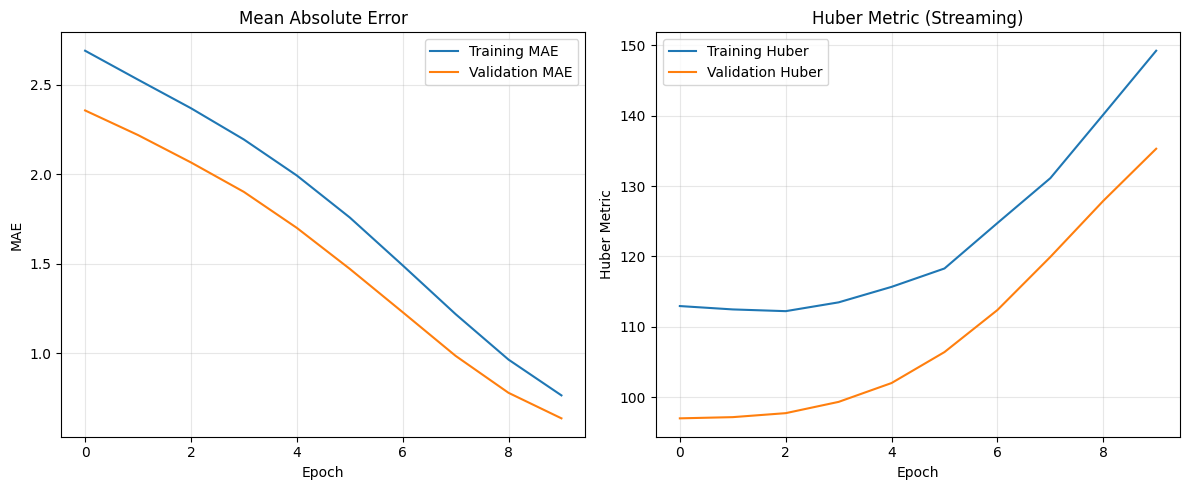

In [61]:
# Use streaming metric in a model
model_streaming = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[10]),
    keras.layers.Dense(1)
])

model_streaming.compile(
    loss="mse",
    optimizer="adam",
    metrics=["mae", HuberMetric(threshold=2.0)]
)

print("Model with streaming Huber metric:")
print("Training...")

history_streaming = model_streaming.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=0
)

print(f"\nFinal metrics:")
print(f"  Training MAE: {history_streaming.history['mae'][-1]:.4f}")
print(f"  Training Huber (streaming): {history_streaming.history['huber_metric'][-1]:.4f}")
print(f"  Validation MAE: {history_streaming.history['val_mae'][-1]:.4f}")
print(f"  Validation Huber (streaming): {history_streaming.history['val_huber_metric'][-1]:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_streaming.history['mae'], label='Training MAE')
plt.plot(history_streaming.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Mean Absolute Error')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_streaming.history['huber_metric'], label='Training Huber')
plt.plot(history_streaming.history['val_huber_metric'], label='Validation Huber')
plt.xlabel('Epoch')
plt.ylabel('Huber Metric')
plt.title('Huber Metric (Streaming)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7.4 Difference Between Simple and Streaming Metrics

Let's visualize the difference between simple (function-based) and streaming (class-based) metrics.

In [62]:
print("Comparison: Simple vs Streaming Metrics\n")
print("=" * 60)

# Simple metric (function)
simple_results = []
y_true_batches = [
    tf.constant([1., 2., 3.]),
    tf.constant([4., 5., 6.]),
    tf.constant([7., 8., 9.])
]
y_pred_batches = [
    tf.constant([1.1, 2.2, 2.9]),
    tf.constant([4.2, 4.8, 6.3]),
    tf.constant([7.1, 7.9, 9.2])
]

print("SIMPLE METRIC (Function-based):")
print("Each batch is evaluated independently, then averaged\n")
for i, (y_true, y_pred) in enumerate(zip(y_true_batches, y_pred_batches)):
    batch_result = tf.reduce_mean(create_huber(2.0)(y_true, y_pred))
    simple_results.append(batch_result.numpy())
    print(f"  Batch {i+1}: {batch_result.numpy():.4f}")

simple_avg = np.mean(simple_results)
print(f"\n  Average across batches: {simple_avg:.4f}")

print("\n" + "=" * 60)

# Streaming metric (class)
print("\nSTREAMING METRIC (Class-based):")
print("All values are accumulated, then divided by total count\n")
streaming_metric = HuberMetric(threshold=2.0)
for i, (y_true, y_pred) in enumerate(zip(y_true_batches, y_pred_batches)):
    streaming_metric.update_state(y_true, y_pred)
    print(f"  After batch {i+1}: {streaming_metric.result().numpy():.4f}")

print(f"\n  Final result: {streaming_metric.result().numpy():.4f}")
print(f"  Total samples: {streaming_metric.count.numpy():.0f}")

print("\n" + "=" * 60)
print("\nDifference:")
print(f"  Simple metric avg: {simple_avg:.4f}")
print(f"  Streaming metric:  {streaming_metric.result().numpy():.4f}")
print(f"  Difference:        {abs(simple_avg - streaming_metric.result().numpy()):.4f}")
print("\nNote: Streaming metrics are more accurate, especially with")
print("      varying batch sizes or when global statistics matter.")

Comparison: Simple vs Streaming Metrics

SIMPLE METRIC (Function-based):
Each batch is evaluated independently, then averaged

  Batch 1: 0.0100
  Batch 2: 0.0283
  Batch 3: 0.0100

  Average across batches: 0.0161


STREAMING METRIC (Class-based):
All values are accumulated, then divided by total count

  After batch 1: 0.0100
  After batch 2: 0.0192
  After batch 3: 0.0161

  Final result: 0.0161
  Total samples: 9


Difference:
  Simple metric avg: 0.0161
  Streaming metric:  0.0161
  Difference:        0.0000

Note: Streaming metrics are more accurate, especially with
      varying batch sizes or when global statistics matter.


## Summary of Part 3

In this section, we covered:

1. **Custom Activation Functions**:
   - Implemented softplus: $f(x) = \log(1 + e^x)$
   - Smooth approximation of ReLU
   - Used as simple functions in layers

2. **Custom Initializers**:
   - Implemented Glorot (Xavier) initialization
   - Controls initial weight distribution
   - Important for training stability

3. **Custom Regularizers**:
   - Implemented L1 regularization
   - Function-based and class-based approaches
   - Penalizes large weights to prevent overfitting

4. **Custom Constraints**:
   - Implemented non-negative constraint
   - Restricts weight values during training
   - Applied after each gradient update

5. **Custom Metrics**:
   - **Simple metrics**: Function-based, averaged over batches
   - **Streaming metrics**: Class-based, maintain state across batches
   - Streaming metrics are more accurate for global statistics

**Key Takeaways:**
- All custom components can be functions for simplicity
- Use classes when you need to save/load models or maintain state
- Streaming metrics provide more accurate measurements than simple metrics
- Regularizers add penalties to the loss, constraints enforce hard limits
- Always implement `get_config()` in custom classes for serialization

**Next Steps:**
In Part 4, we'll explore:
- Custom layers (stateless and stateful)
- Custom models
- Computing gradients using autodiff
- Custom training loops

# Part 4: Custom Layers, Models, Autodiff, and Custom Training Loops

This final part covers:
- Custom layers (stateless and stateful)
- Custom models using the Subclassing API
- Losses based on model internals (reconstruction loss example)
- Computing gradients with `tf.GradientTape`
- A worked example of a custom training loop


# 8. Custom Layers

We implement a stateless Lambda-like layer and two stateful layers: `MyDense` and `MyGaussianNoise` (which behaves differently during training vs inference).

In [63]:
# Stateless layer (Lambda-like example)
exponential_layer = keras.layers.Lambda(lambda x: tf.exp(x))

# Stateful custom Dense layer
class MyDense(keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = keras.activations.get(activation)
    
    def build(self, batch_input_shape):
        self.kernel = self.add_weight(
            name="kernel",
            shape=[batch_input_shape[-1], self.units],
            initializer="glorot_normal")
        self.bias = self.add_weight(
            name="bias",
            shape=[self.units],
            initializer="zeros")
        super().build(batch_input_shape)
    
    def call(self, X):
        return self.activation(tf.matmul(X, self.kernel) + self.bias)
    
    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "units": self.units,
                "activation": keras.activations.serialize(self.activation)}

# Layer with training behavior (Gaussian noise)
class MyGaussianNoise(keras.layers.Layer):
    def __init__(self, stddev, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev
    
    def call(self, X, training=None):
        if training:
            noise = tf.random.normal(tf.shape(X), stddev=self.stddev)
            return X + noise
        else:
            return X
    
    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "stddev": self.stddev}

# Quick tests (building layers)
_ = MyDense(5, activation="elu")(tf.zeros([2, 10]))
_ = MyGaussianNoise(0.1)(tf.zeros([2, 10]), training=True)
print("Custom layers built and tested on dummy input")

Custom layers built and tested on dummy input


# 9. Custom Models

We'll implement a `ResidualBlock` and a `ResidualRegressor` using the Subclassing API. These demonstrate skip connections and assembling custom layers.


In [64]:
class ResidualBlock(keras.layers.Layer):
    def __init__(self, n_layers, n_neurons, **kwargs):
        super().__init__(**kwargs)
        self.hidden = [keras.layers.Dense(n_neurons, activation="elu",
                                         kernel_initializer="he_normal")
                      for _ in range(n_layers)]
    
    def call(self, inputs):
        Z = inputs
        for layer in self.hidden:
            Z = layer(Z)
        return inputs + Z  # Skip connection

class ResidualRegressor(keras.Model):
    def __init__(self, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = keras.layers.Dense(30, activation="elu",
                                         kernel_initializer="he_normal")
        self.block1 = ResidualBlock(2, 30)
        self.block2 = ResidualBlock(2, 30)
        self.out = keras.layers.Dense(output_dim)
    
    def call(self, inputs):
        Z = self.hidden1(inputs)
        for _ in range(1 + 3):
            Z = self.block1(Z)
        Z = self.block2(Z)
        return self.out(Z)

# Build and test the model on dummy data
res_model = ResidualRegressor(output_dim=1)
_dummy = tf.zeros([5, 10])
_dummy_out = res_model(_dummy)
print("ResidualRegressor built and ran on dummy input; output shape:", _dummy_out.shape)

ResidualRegressor built and ran on dummy input; output shape: (5, 1)


In [65]:
# 10. Losses Based on Model Internals

# Example: ReconstructingRegressor adds a reconstruction loss from an internal layer
class ReconstructingRegressor(keras.Model):
    def __init__(self, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.hidden = [keras.layers.Dense(30, activation="selu",
                                         kernel_initializer="lecun_normal")
                      for _ in range(5)]
        self.out = keras.layers.Dense(output_dim)
    
    def build(self, batch_input_shape):
        n_inputs = batch_input_shape[-1]
        self.reconstruct = keras.layers.Dense(n_inputs)
        super().build(batch_input_shape)
    
    def call(self, inputs):
        Z = inputs
        for layer in self.hidden:
            Z = layer(Z)
        reconstruction = self.reconstruct(Z)
        recon_loss = tf.reduce_mean(tf.square(reconstruction - inputs))
        self.add_loss(0.05 * recon_loss)  # Add reconstruction loss to model.losses
        return self.out(Z)

# Test the reconstructing model
recon_model = ReconstructingRegressor(output_dim=1)
_ = recon_model(tf.zeros([4, 10]))
print("ReconstructingRegressor built and computed reconstruction loss on dummy input")

ReconstructingRegressor built and computed reconstruction loss on dummy input


# 11. Computing Gradients Using Autodiff

Demonstrate basic gradient computation with `tf.GradientTape`, persistent tapes, watching non-variable tensors, stopping gradients, and a simple custom gradient.

In [66]:
def f(w1, w2):
    return 3 * w1 ** 2 + 2 * w1 * w2

# Basic gradient computation
w1, w2 = tf.Variable(5.), tf.Variable(3.)
with tf.GradientTape() as tape:
    z = f(w1, w2)

gradients = tape.gradient(z, [w1, w2])
print("Gradients (dz/dw1, dz/dw2):", [g.numpy() for g in gradients])

# Persistent tape
with tf.GradientTape(persistent=True) as tape:
    z = f(w1, w2)

dz_dw1 = tape.gradient(z, w1)
dz_dw2 = tape.gradient(z, w2)
print("Persistent tape gradients:", dz_dw1.numpy(), dz_dw2.numpy())

del tape

# Watching non-variable tensors
c1, c2 = tf.constant(5.), tf.constant(3.)
with tf.GradientTape() as tape:
    tape.watch(c1)
    tape.watch(c2)
    z = f(c1, c2)

gradients_constants = tape.gradient(z, [c1, c2])
print("Gradients wrt constants:", [g.numpy() for g in gradients_constants])

# Stopping gradients
def f2(w1, w2):
    return 3 * w1 ** 2 + tf.stop_gradient(2 * w1 * w2)

with tf.GradientTape() as tape:
    z2 = f2(w1, w2)

gradients2 = tape.gradient(z2, [w1, w2])
print("Gradients with stop_gradient (w2 none):", gradients2)

# Custom gradient example
@tf.custom_gradient
def my_better_softplus(z):
    exp = tf.exp(z)
    def grad(dy):
        return dy / (1 + 1 / exp)
    return tf.math.log(exp + 1), grad

# Test custom gradient function
x = tf.constant(1.0)
with tf.GradientTape() as tape:
    tape.watch(x)
    y = my_better_softplus(x)

dy_dx = tape.gradient(y, x)
print("Custom gradient dy/dx at x=1.0:", dy_dx.numpy())

Gradients (dz/dw1, dz/dw2): [36.0, 10.0]
Persistent tape gradients: 36.0 10.0
Gradients wrt constants: [36.0, 10.0]
Gradients with stop_gradient (w2 none): [<tf.Tensor: shape=(), dtype=float32, numpy=30.0>, None]
Custom gradient dy/dx at x=1.0: 0.7310586


# 12. Custom Training Loop Example

We'll build a small model and train it using a custom training loop with `tf.GradientTape` so you can see the lower-level mechanics (loss computation, gradients, optimizer updates, metrics, and applying constraints).


In [69]:
for epoch in range(1, n_epochs + 1):
    print(f"Epoch {epoch}/{n_epochs}")
    train_loss.reset_state()
    train_mae.reset_state()

    for step in range(1, n_steps + 1):
        X_batch, y_batch = random_batch(X_train, y_train, batch_size)

        with tf.GradientTape() as tape:
            y_pred = model(X_batch, training=True)
            main_loss = loss_fn(y_batch, y_pred)
            loss_value = tf.add_n([main_loss] + model.losses)

        gradients = tape.gradient(loss_value, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        train_loss.update_state(loss_value)
        train_mae.update_state(y_batch, y_pred)

        if step % 50 == 0 or step == n_steps:
            print(
                f"  Step {step}/{n_steps} "
                f"- loss: {train_loss.result().numpy():.4f}, "
                f"mae: {train_mae.result().numpy():.4f}"
            )


Epoch 1/5
  Step 31/31 - loss: 4.4408, mae: 1.4252
Epoch 2/5
  Step 31/31 - loss: 1.0275, mae: 0.5635
Epoch 3/5
  Step 31/31 - loss: 0.8287, mae: 0.4651
Epoch 4/5
  Step 31/31 - loss: 0.7509, mae: 0.4515
Epoch 5/5
  Step 31/31 - loss: 0.6633, mae: 0.4332


## Final Summary and Next Steps

This notebook covered all core concepts from Chapter 12:
- Tensor basics, operations, and NumPy interoperability
- Variables and updates
- Other data structures (sparse, ragged, strings, sets)
- Custom losses, activations, initializers, regularizers, and constraints
- Custom metrics (function and streaming)
- Custom layers and models
- Autodiff and custom training loop

Next: If you want, I can:
- Run the notebook cells and capture outputs here
- Split this into separate notebooks per part
- Add exercises and more visualizations (e.g., TensorBoard)

Tell me which you'd like next.